<a href="https://colab.research.google.com/github/luccasnn/segmentacao-clientes/blob/main/segmentacao_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# dataset real - > Mall Customers
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nColunas:", df.columns.tolist())
print("\nValores nulos:")
print(df.isnull().sum())
df.head()

Shape: (200, 5)

Colunas: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Valores nulos:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


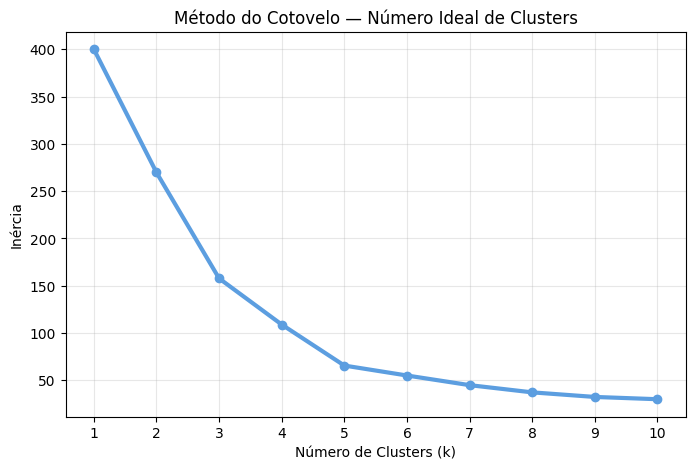

Olha onde a curva 'dobra' — esse é o k ideal


In [6]:
# seleciona as features principais
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# padroniza
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# metodo cotovelo
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', color='#5c9ee0', linewidth=3)
plt.title('Método do Cotovelo — Número Ideal de Clusters')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.savefig('cotovelo.png', dpi=150, bbox_inches='tight')
plt.show()

print("Olha onde a curva 'dobra' — esse é o k ideal")

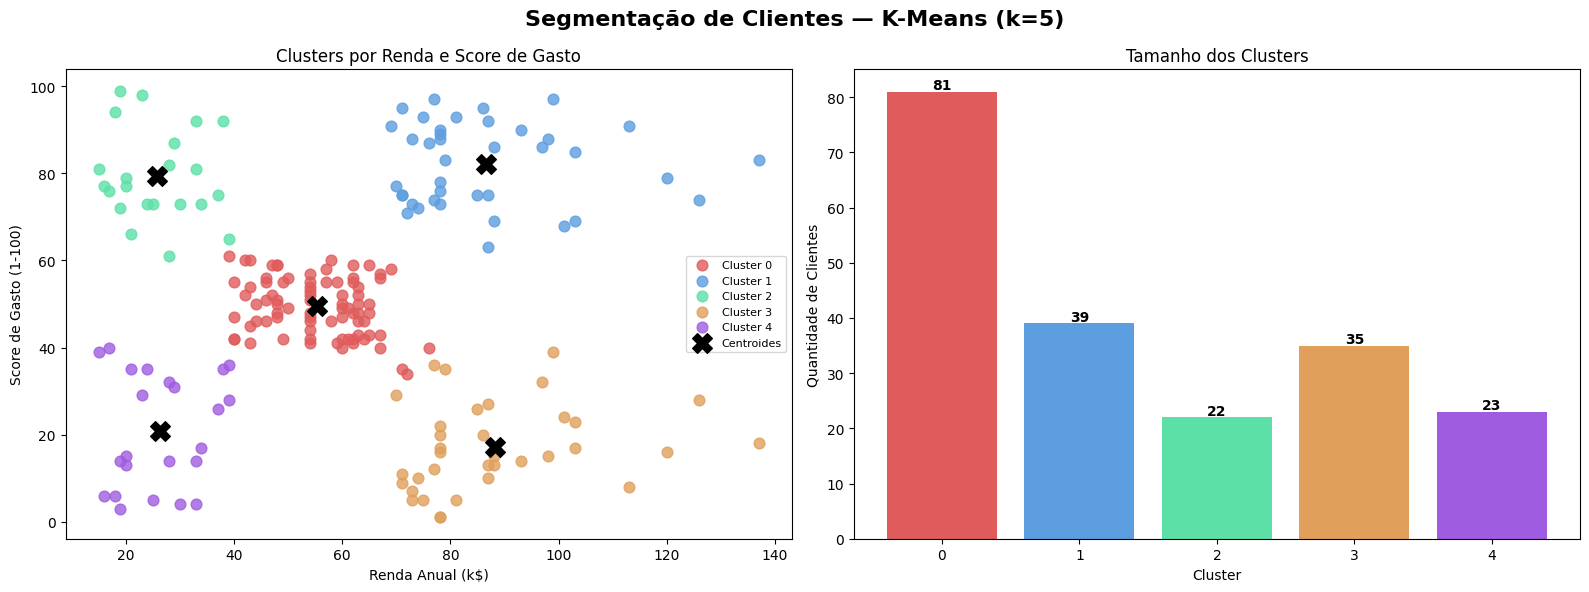


Média por cluster:
         Annual Income (k$)  Spending Score (1-100)   Age
Cluster                                                  
0                      55.3                    49.5  42.7
1                      86.5                    82.1  32.7
2                      25.7                    79.4  25.3
3                      88.2                    17.1  41.1
4                      26.3                    20.9  45.2


In [5]:
# Treina com k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualização 2D
cores = ['#e05c5c', '#5c9ee0', '#5ce0a8', '#e0a05c', '#a05ce0']
nomes = ['Baixa renda, baixo gasto', 'Alta renda, baixo gasto',
         'Renda média, gasto médio', 'Baixa renda, alto gasto', 'Alta renda, alto gasto']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Segmentação de Clientes — K-Means (k=5)', fontsize=16, fontweight='bold')

# clusters por renda e score
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    axes[0].scatter(cluster_data['Annual Income (k$)'],
                   cluster_data['Spending Score (1-100)'],
                   c=cores[i], label=f'Cluster {i}', s=60, alpha=0.8)

# centroides
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(centroids[:, 0], centroids[:, 1],
               c='black', marker='X', s=200, zorder=5, label='Centroides')
axes[0].set_title('Clusters por Renda e Score de Gasto')
axes[0].set_xlabel('Renda Anual (k$)')
axes[0].set_ylabel('Score de Gasto (1-100)')
axes[0].legend(fontsize=8)

# tamanho de cada cluster
cluster_counts = df['Cluster'].value_counts().sort_index()
axes[1].bar(range(5), cluster_counts.values, color=cores)
axes[1].set_title('Tamanho dos Clusters')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Quantidade de Clientes')
for i, v in enumerate(cluster_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('segmentacao_clientes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMédia por cluster:")
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean().round(1))

In [9]:
from google.colab import files
files.download('cotovelo.png')
files.download('segmentacao_clientes.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>